# Credit Risk — Exploratory Data Analysis

**Dataset**: UCI Default of Credit Card Clients  
**Records**: 30,000 | **Features**: 23 | **Target**: `default` (1 = defaulted next month)

## Why EDA First?
EDA is not optional — it's the foundation of every good ML project. Before building a model:
- We need to understand what each feature actually means
- Spot data quality issues (wrong types, impossible values) early
- Understand class imbalance — critical for risk prediction
- Identify which features are likely predictive

Skipping EDA leads to silent model failures that are very hard to debug later.

In [1]:
import sys
sys.path.insert(0, "..")  # make src/ importable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")
print("Imports OK")

Imports OK


## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv("../data/raw/credit_risk/credit_risk.csv")
print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Shape: (30000, 25)
Memory: 6.0 MB


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

In [4]:
# Statistical summary of numeric features
df.describe().round(2)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


## 2. Missing Values

Missing data handling strategy depends on:
- **<5%** missing → impute (median for skewed data, mean for symmetric)
- **5-40%** missing → impute with caution, add a binary 'was_missing' indicator feature
- **>40%** missing → consider dropping the column entirely

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percent": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0]

if len(missing_df) == 0:
    print("No missing values — this dataset is complete!")
else:
    display(missing_df)
    # Visualize
    plt.figure(figsize=(10, 4))
    missing_df["Percent"].plot(kind="bar")
    plt.title("Missing Values by Column (%)")
    plt.ylabel("Missing %")
    plt.tight_layout()
    plt.show()

No missing values — this dataset is complete!


## 3. Target Variable Distribution

**Class imbalance** is the most important characteristic of this dataset for modeling.
With a ~22% positive class, a naive 'always predict No Default' model gets ~78% accuracy.
This is why we use: Precision, Recall, F1, ROC-AUC — not just accuracy.

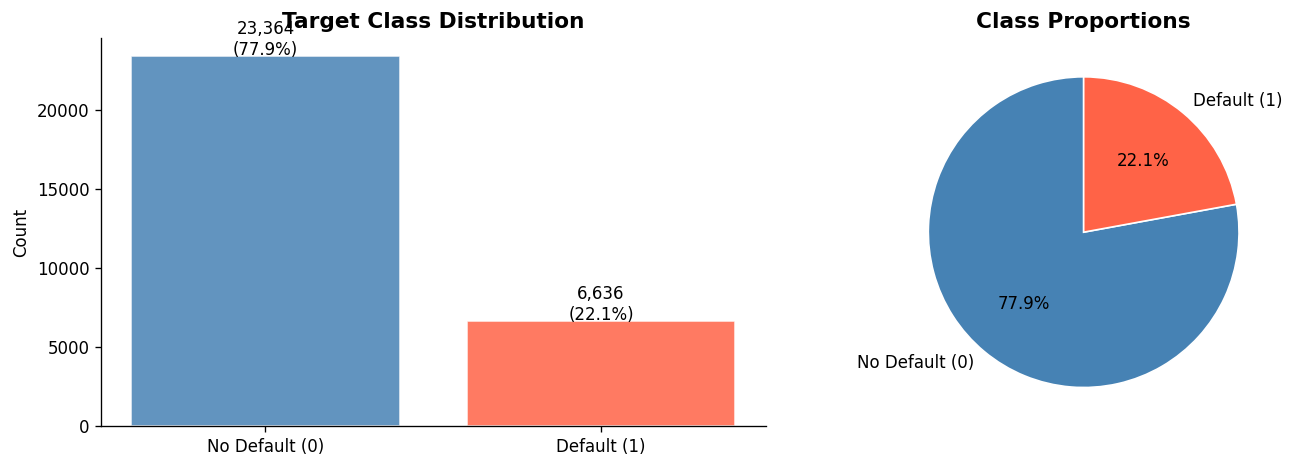

Class imbalance ratio: 3.5:1 (negative:positive)
Positive class rate: 22.1%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["default"].value_counts()
labels = ["No Default (0)", "Default (1)"]
colors = ["steelblue", "tomato"]

axes[0].bar(labels, counts.values, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title("Target Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    pct = v / len(df) * 100
    axes[0].text(i, v + 100, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title("Class Proportions", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig('../models/credit_risk/eda_target_distribution.png', bbox_inches='tight')
plt.show()
print(f'Class imbalance ratio: {counts[0]/counts[1]:.1f}:1 (negative:positive)')
print(f'Positive class rate: {counts[1]/len(df)*100:.1f}%')

## 4. Demographic Feature Analysis

We compare each feature's distribution between defaulters and non-defaulters.
A feature where the distributions differ significantly is likely predictive.

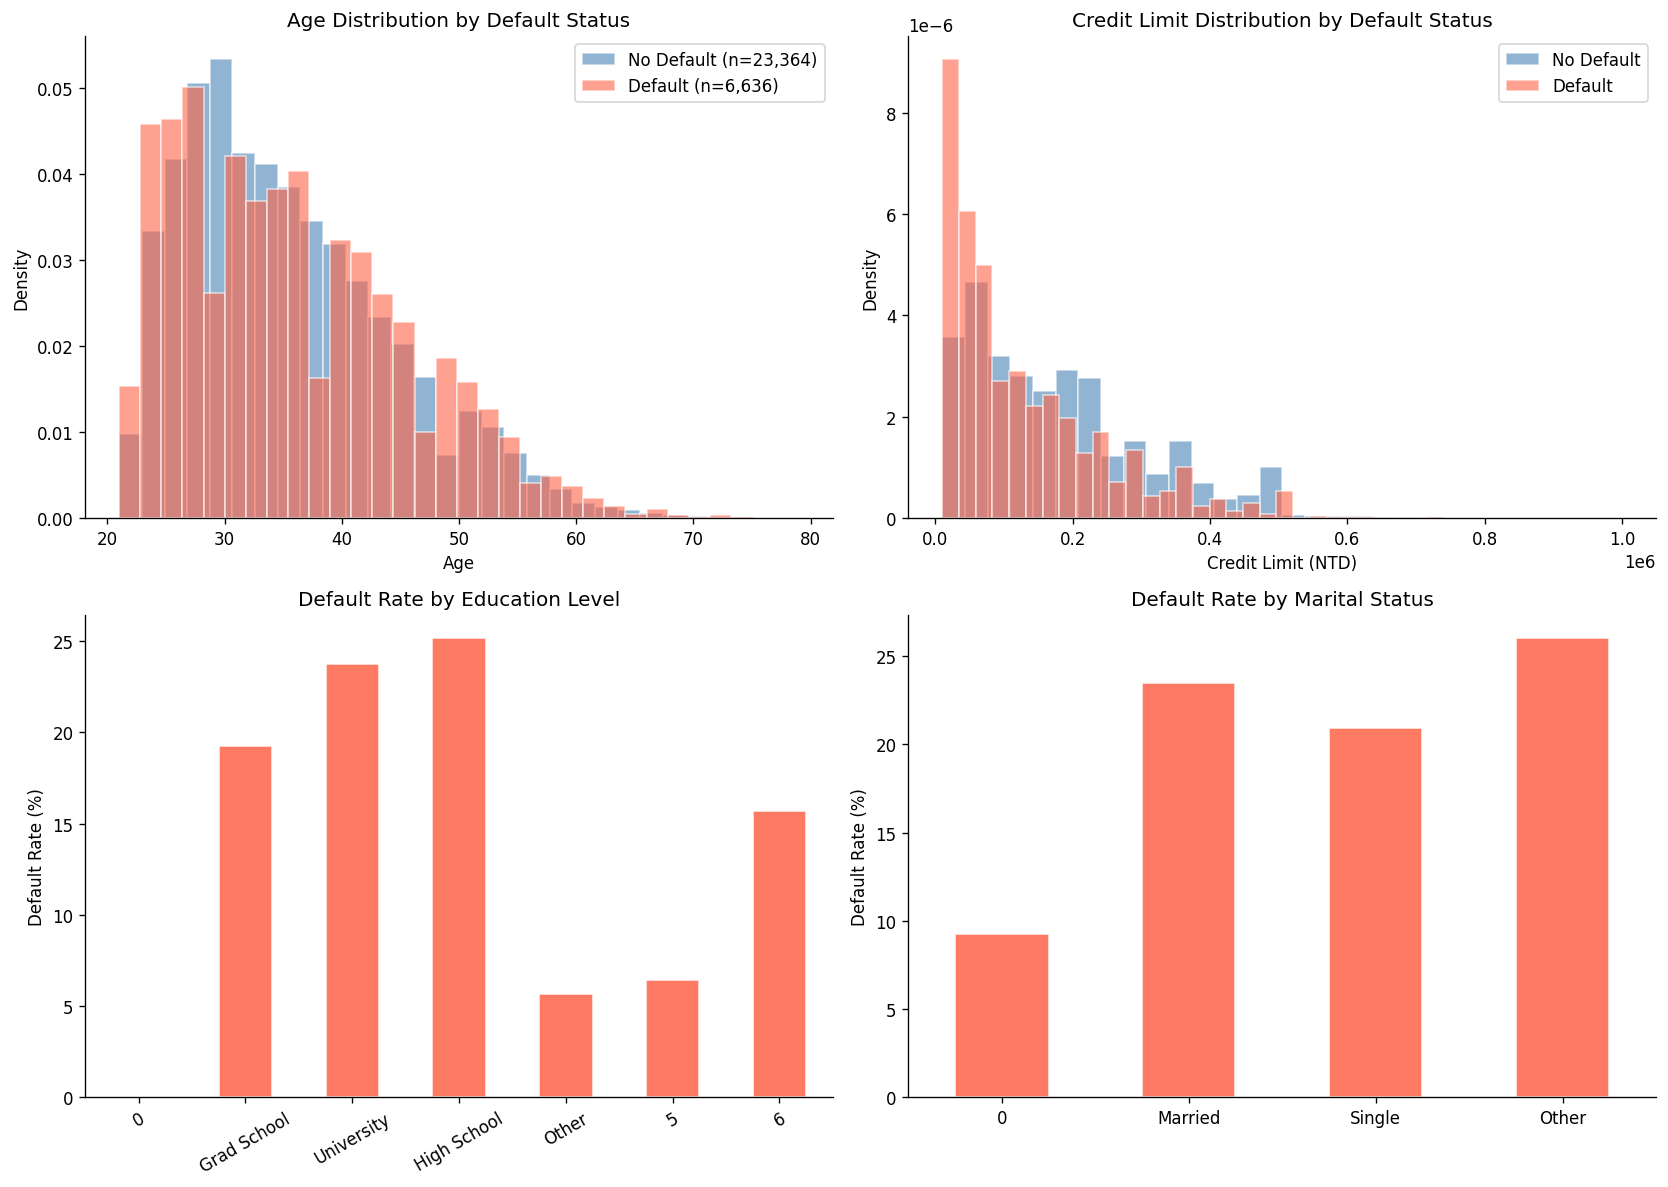

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age
for label in [0, 1]:
    color = 'steelblue' if label == 0 else 'tomato'
    lbl = 'No Default' if label == 0 else 'Default'
    subset = df[df["default"] == label]["AGE"]
    axes[0,0].hist(subset, bins=30, alpha=0.6, color=color,
                  label=f'{lbl} (n={len(subset):,})', density=True, edgecolor='white')
axes[0,0].set_title("Age Distribution by Default Status")
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Density")
axes[0,0].legend()

# Credit Limit
for label in [0, 1]:
    color = 'steelblue' if label == 0 else 'tomato'
    lbl = 'No Default' if label == 0 else 'Default'
    subset = df[df["default"] == label]["LIMIT_BAL"]
    axes[0,1].hist(subset, bins=30, alpha=0.6, color=color,
                  density=True, edgecolor='white', label=lbl)
axes[0,1].set_title("Credit Limit Distribution by Default Status")
axes[0,1].set_xlabel("Credit Limit (NTD)")
axes[0,1].set_ylabel("Density")
axes[0,1].legend()

# Education vs default rate
edu_default = df.groupby(["EDUCATION", "default"]).size().unstack(fill_value=0)
edu_pct = edu_default.div(edu_default.sum(axis=1), axis=0) * 100
edu_labels = {1: 'Grad School', 2: 'University', 3: 'High School', 4: 'Other'}
edu_pct.index = [edu_labels.get(i, str(i)) for i in edu_pct.index]
edu_pct[1].plot(kind='bar', ax=axes[1,0], color='tomato', alpha=0.85, edgecolor='white')
axes[1,0].set_title("Default Rate by Education Level")
axes[1,0].set_ylabel("Default Rate (%)")
axes[1,0].tick_params(axis='x', rotation=30)

# Marriage vs default rate
mar_default = df.groupby(["MARRIAGE", "default"]).size().unstack(fill_value=0)
mar_pct = mar_default.div(mar_default.sum(axis=1), axis=0) * 100
mar_labels = {1: 'Married', 2: 'Single', 3: 'Other'}
mar_pct.index = [mar_labels.get(i, str(i)) for i in mar_pct.index]
mar_pct[1].plot(kind='bar', ax=axes[1,1], color='tomato', alpha=0.85, edgecolor='white')
axes[1,1].set_title("Default Rate by Marital Status")
axes[1,1].set_ylabel("Default Rate (%)")
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../models/credit_risk/eda_demographics.png', bbox_inches='tight')
plt.show()

## 5. Repayment History — The Strongest Predictor

PAY_0 (most recent month's repayment status) is almost always the strongest
predictor in credit models. Positive values = months delayed; -1 = paid on time.
This confirms the intuition: **past behavior predicts future behavior.**

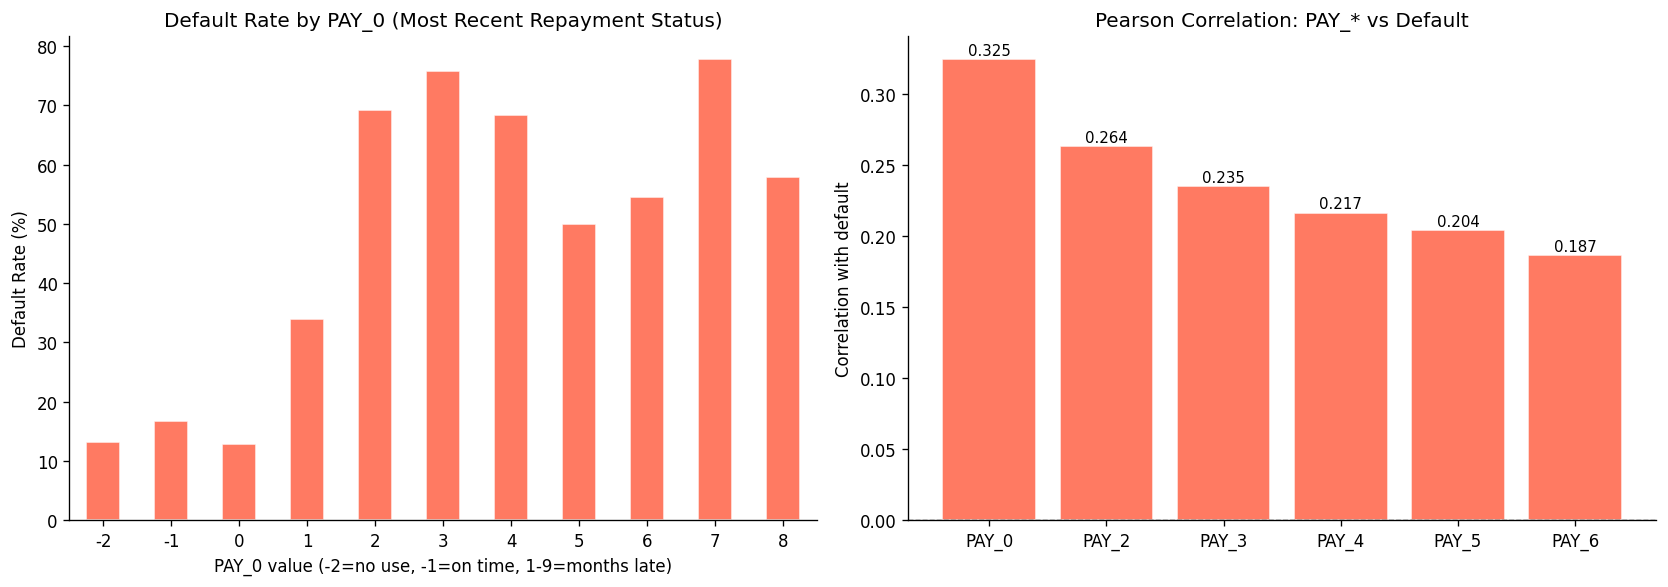

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PAY_0 vs default rate
pay_default = df.groupby(["PAY_0", "default"]).size().unstack(fill_value=0)
pay_pct = pay_default.div(pay_default.sum(axis=1), axis=0) * 100
pay_pct[1].plot(kind='bar', ax=axes[0], color='tomato', alpha=0.85, edgecolor='white')
axes[0].set_title("Default Rate by PAY_0 (Most Recent Repayment Status)")
axes[0].set_xlabel("PAY_0 value (-2=no use, -1=on time, 1-9=months late)")
axes[0].set_ylabel("Default Rate (%)")
axes[0].tick_params(axis='x', rotation=0)

# Correlation of all PAY columns with target
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
correlations = [df[col].corr(df["default"]) for col in pay_cols]
bar_colors = ['tomato' if c > 0 else 'steelblue' for c in correlations]
bars = axes[1].bar(pay_cols, correlations, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_title("Pearson Correlation: PAY_* vs Default")
axes[1].set_ylabel("Correlation with default")
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, correlations):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../models/credit_risk/eda_repayment_history.png', bbox_inches='tight')
plt.show()

## 6. Bill Amounts and Payments

BILL_AMT vs PAY_AMT ratios reveal how much of their debt borrowers are actually paying off.

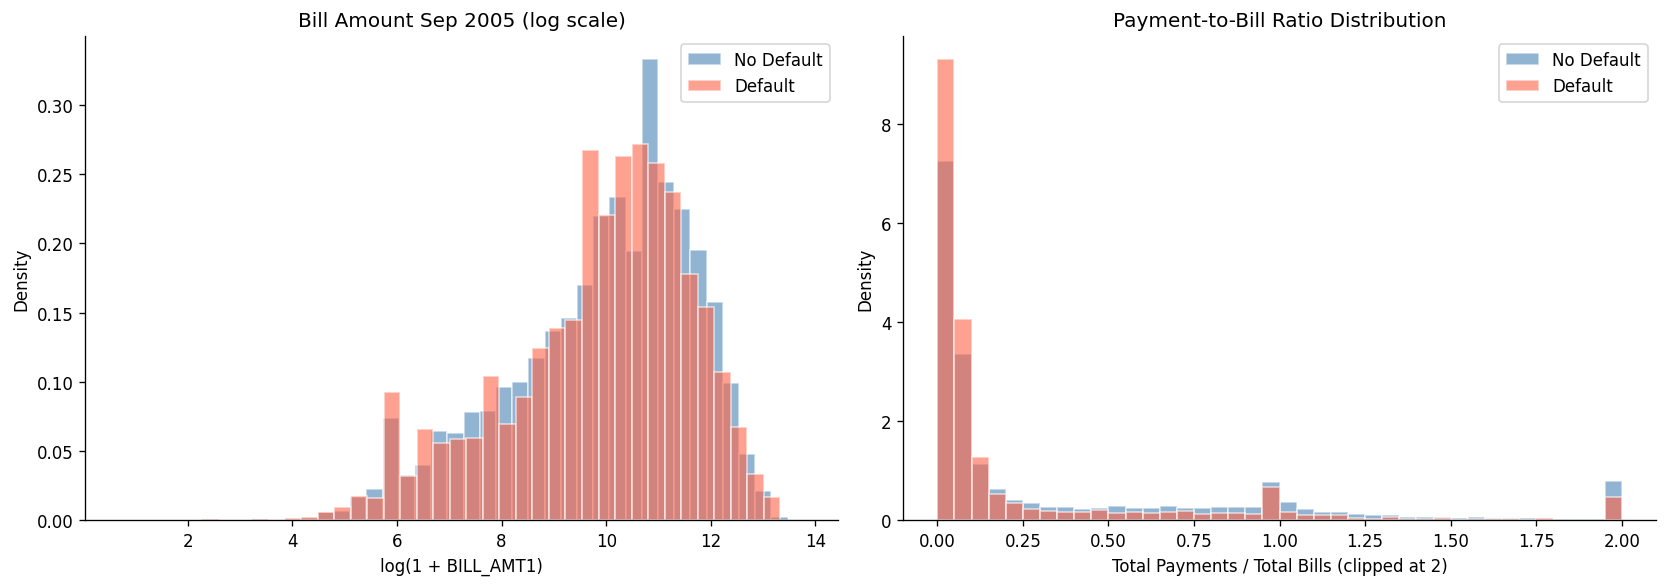

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BILL_AMT1 distribution (log scale)
for label in [0, 1]:
    color = 'steelblue' if label == 0 else 'tomato'
    lbl = 'No Default' if label == 0 else 'Default'
    amt = df[df["default"] == label]["BILL_AMT1"]
    amt_positive = amt[amt > 0]
    axes[0].hist(np.log1p(amt_positive), bins=40, alpha=0.6, color=color,
                 label=lbl, density=True, edgecolor='white')
axes[0].set_title("Bill Amount Sep 2005 (log scale)")
axes[0].set_xlabel("log(1 + BILL_AMT1)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Payment ratio
df_tmp = df.copy()
total_bill = df_tmp[['BILL_AMT1','BILL_AMT2','BILL_AMT3']].sum(axis=1)
total_pay  = df_tmp[['PAY_AMT1','PAY_AMT2','PAY_AMT3']].sum(axis=1)
df_tmp['payment_ratio'] = total_pay / (total_bill + 1)  # +1 avoids division by zero
df_tmp['payment_ratio'] = df_tmp['payment_ratio'].clip(0, 2)  # clip extreme values

for label in [0, 1]:
    color = 'steelblue' if label == 0 else 'tomato'
    lbl = 'No Default' if label == 0 else 'Default'
    subset = df_tmp[df_tmp['default'] == label]['payment_ratio']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, density=True,
                 edgecolor='white', label=lbl)
axes[1].set_title('Payment-to-Bill Ratio Distribution')
axes[1].set_xlabel('Total Payments / Total Bills (clipped at 2)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/credit_risk/eda_payments.png', bbox_inches='tight')
plt.show()

## 7. Correlation Matrix

High inter-feature correlation (multicollinearity) matters differently by model type:
- **Logistic Regression**: very sensitive — correlated features cause unstable coefficients
- **XGBoost**: handles it well — trees split on one feature at a time
- **SHAP**: multicollinearity can split importance across correlated features

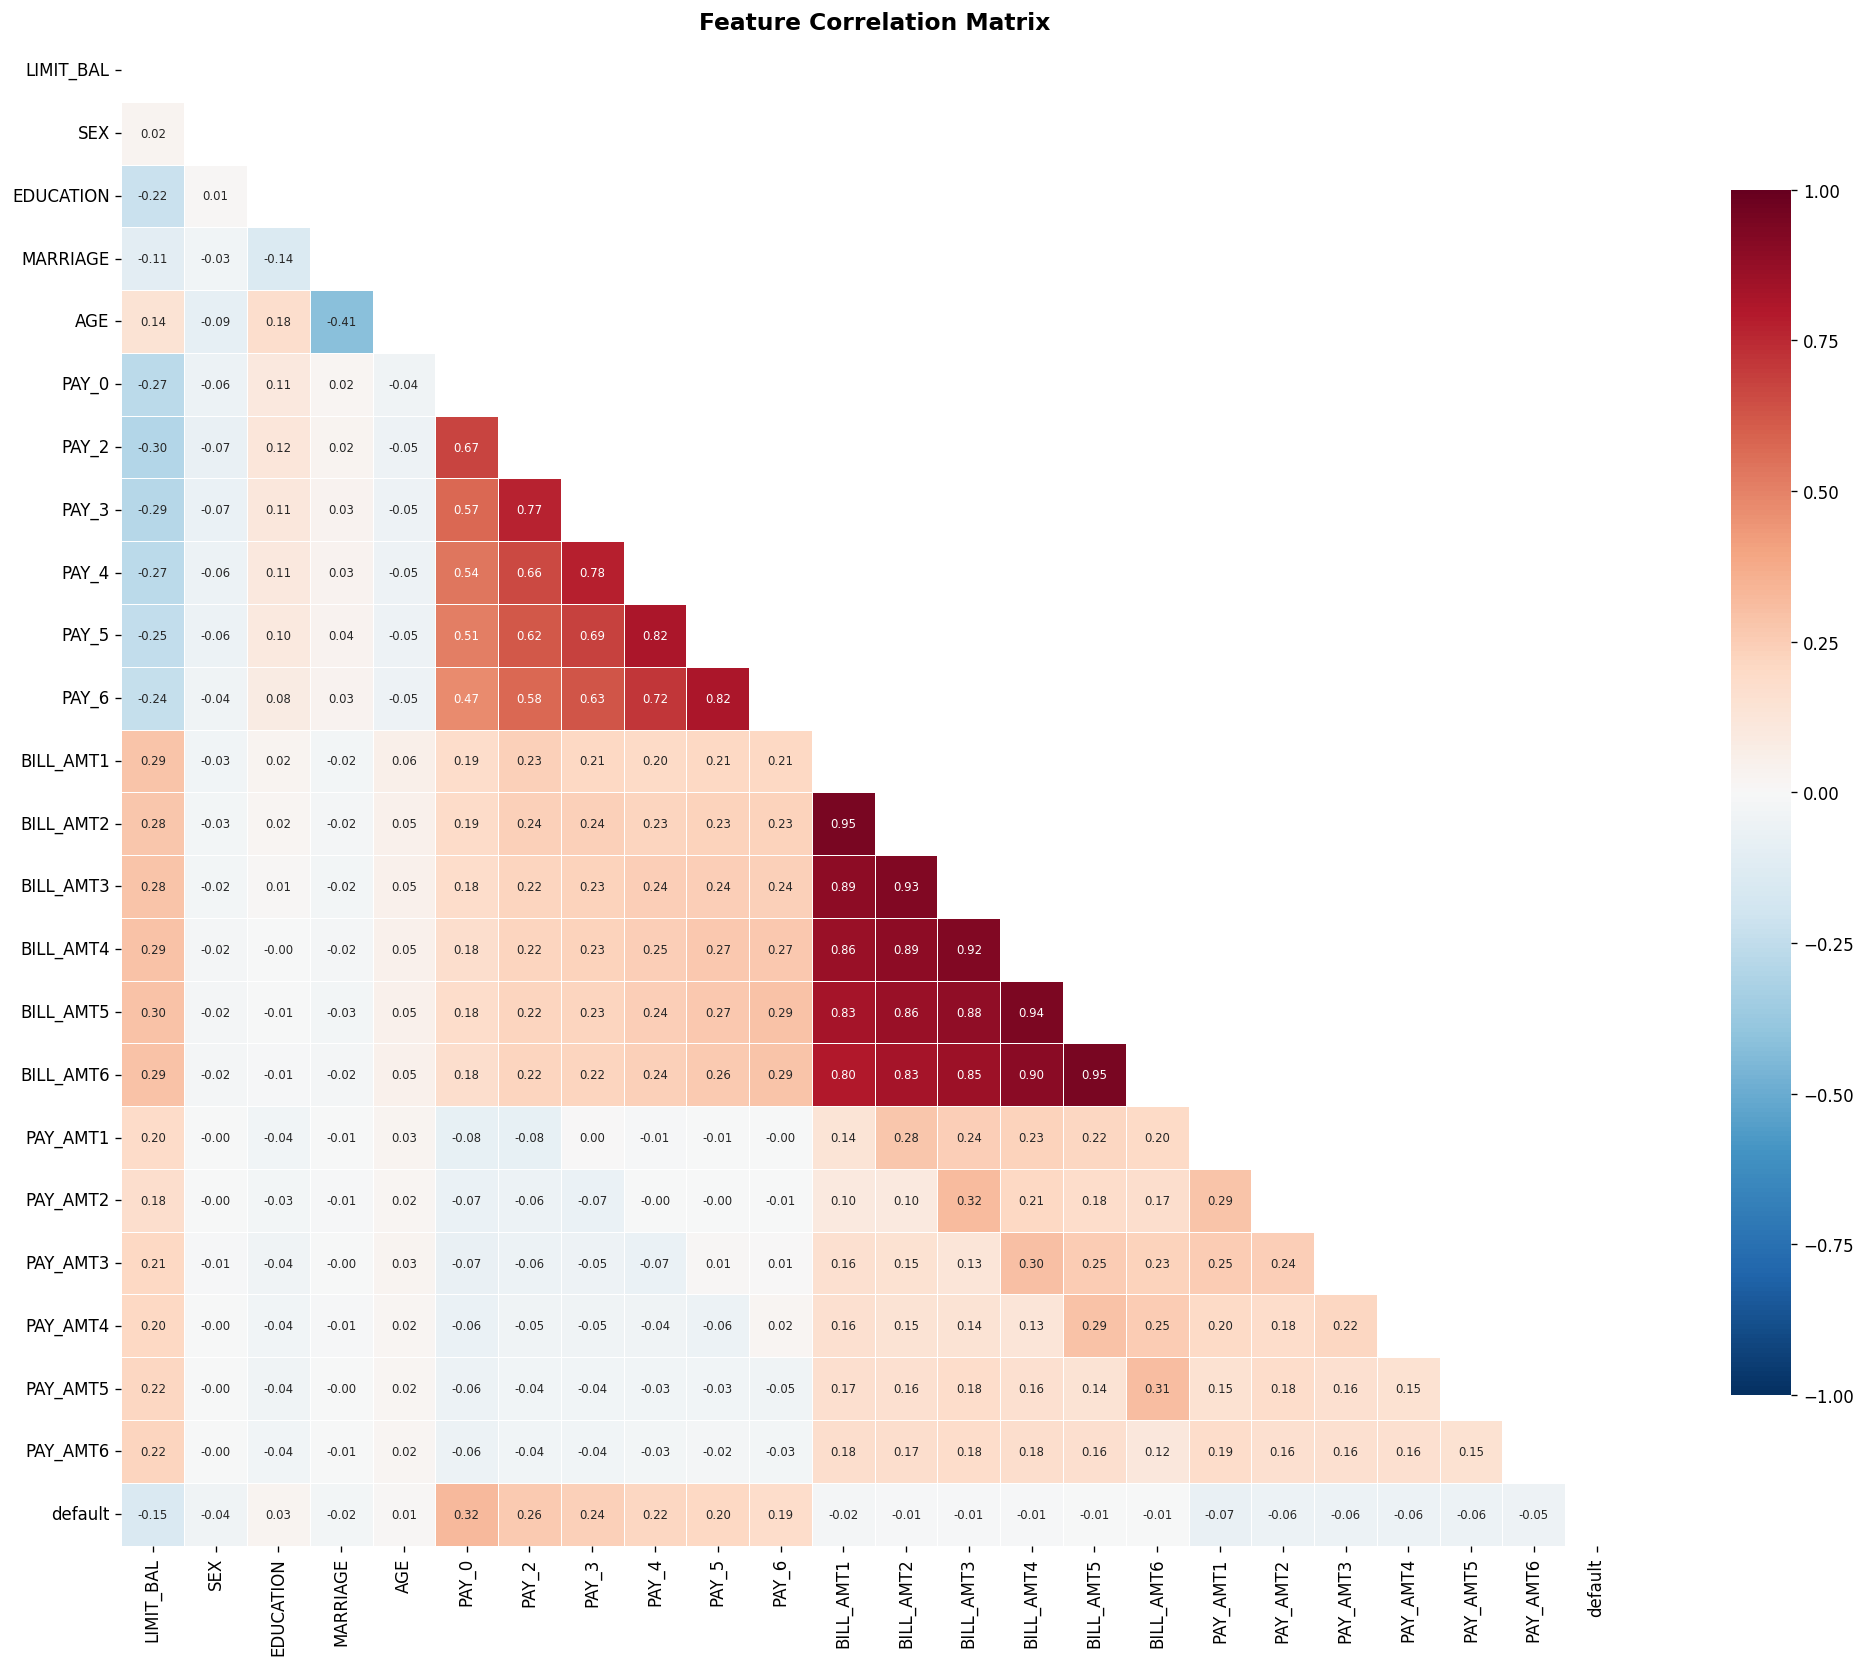

Top 10 features correlated with default (by absolute Pearson r):
PAY_0        0.3248
PAY_2        0.2636
PAY_3        0.2353
PAY_4        0.2166
PAY_5        0.2041
PAY_6        0.1869
LIMIT_BAL    0.1535
PAY_AMT1     0.0729
PAY_AMT2     0.0586
PAY_AMT4     0.0568


In [10]:
feature_cols = [c for c in df.columns if c not in ['ID', 'default']]
corr_matrix = df[feature_cols + ['default']].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/credit_risk/eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Top features correlated with target
target_corr = corr_matrix['default'].drop('default').abs().sort_values(ascending=False)
print('Top 10 features correlated with default (by absolute Pearson r):')
print(target_corr.head(10).round(4).to_string())

## 8. EDA Summary — What We Learned

| Finding | Implication |
|---|---|
| No missing values | No imputation needed; pipeline adds it defensively |
| 22% positive class | Use `scale_pos_weight` in XGBoost; tune decision threshold |
| PAY_0–PAY_6 most predictive | Recent repayment history dominates |
| High correlation in BILL_AMT group | XGBoost handles it; SHAP will split importance |
| Higher LIMIT_BAL → lower default | Wealthier borrowers default less |

### Feature Engineering Ideas for Phase 2
```python
# Aggregate repayment trend
df['pay_delay_mean']    = df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean(axis=1)
df['pay_delay_max']     = df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].max(axis=1)

# Financial ratios
df['total_bill']    = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3']].sum(axis=1)
df['total_payment'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3']].sum(axis=1)
df['payment_ratio'] = df['total_payment'] / (df['total_bill'] + 1)
```